# Part 1 — Understand AI, ML, and DL

> # **What is Artificial Intelligence (AI)?**
- Artificial Intelligence (AI) is a broad field where machines are designed to think, learn, and make decisions like humans.
- Examples:
    - Voice assistants (like Siri, Alexa)
    - Self-driving cars
    - Chatbots (like ChatGPT)

------------------------------------
> # **What is Machine Learning (ML)?**
- Machine Learning (ML) is a subset of AI that allows machines to learn from data instead of being explicitly programmed.
- Examples:
     - Email spam detection
     - Fraud detection
--------------------------
> # **What is Deep Learning (DL)?**
- Deep Learning (DL) is a subset of Machine Learning that uses neural networks (like the human brain) to learn from large amounts of data.
- Example:
     - Face recognition
     - Voice recognition
     - Self-driving car vision
-----------------------------

> # **Draw or add a simple diagram showing how AI - ML - DL are related**
> ###  **Relationship Diagram: AI → ML → DL**

```
┌─────────────────────────────────────────────────────┐
│                ARTIFICIAL INTELLIGENCE              │
│                                                     │
│   ┌─────────────────────────────────────────────┐   │
│   │               MACHINE LEARNING              │   │
│   │                                             │   │
│   │   ┌─────────────────────────────────────┐   │   │
│   │   │            DEEP LEARNING            │   │   │
│   │   └─────────────────────────────────────┘   │   │
│   └─────────────────────────────────────────────┘   │
└─────────────────────────────────────────────────────┘
```
> **DL ⊏ ML ⊏ AI** — Each inner circle is a more specialised form of the outer.
---

> # **Explain why learning ML is useful today**
- **Data is everywhere** — every click, transaction, and sensor reading creates data. ML turns raw data into actionable intelligence.
- **Automation at scale** — ML automates complex decision-making that would be impossible to hand-code.
- **Career demand** — ML/AI skills are among the most sought-after across every industry globally.
- **Competitive advantage** — Companies using ML outperform competitors in personalisation, fraud detection, logistics, and more.

----------------------------------
> # **Give 2 real-world examples of ML**


### **1.Ride-Sharing Price Prediction**
- Apps like Uber use ML to calculate fares
- It considers:
    - Demand (rush hours)
    - Distance
    - Traffic

### **2.Credit Card Fraud Detection**
- Banks use ML to detect unusual transactions
- It checks:
    - Spending patterns
    - Location changes
    - Transaction amount

### **3.Disease Prediction (Healthcare)**
- ML helps doctors predict diseases like:
    - Diabetes
    - Heart disease

------------------------------------------

# Part 2 — Choose Your Problem

> ##  **Dataset: Job Salary Prediction**
**Source:** Kaggle — `job_salary_prediction_dataset.csv`  
**Rows:** 250,000 | **Columns:** 10

---
> ## **Is this supervised or unsupervised?**
**Supervised** — We have labelled salary data for every record.
---
> ## **Is it classification or regression?**
**Regression** — Salary is a continuous numerical value.
---
> ## **What is the target variable?**
`salary` is the Target Variable.
---
> ## **What does success look like?**
A successful model will predict salary within a reasonable margin (low MAE), explain most of the variance in salary (R2 > 0.7), and generalise well to unseen records.
---

# **Part 3 — Choose an Algorithm**

> ## **List 3 ML algorithms that could solve your problem**
1. **Linear Regression** : Simple and interpretable baseline; works well if salary has a roughly linear relationship with features like experience and skills
2. **Decision Tree Regressor** : Handles non-linear relationships and mixed feature types naturally; captures interactions between education and experience
3. **K-Nearest Neighbors (KNN) Regressor** : Predicts salary by averaging salaries of the K most similar employees — intuitive and powerful for dense, structured tabular data
---
> # **Chosen Algorithm: K-Nearest Neighbors Regressor**

> **Why KNN?**

> KNN is a **non-parametric, instance-based** algorithm that makes no assumptions about the underlying data distribution. For a salary dataset, this is ideal because salary is influenced by a combination of factors (experience × education × industry × location) that interact in complex, non-linear ways. KNN captures this naturally by finding employees with similar profiles and averaging their salaries.
---

# **Part 4 — Explore and Prepare Data**

## **4.1 — Basic Data Exploration (EDA)**
- Shape of data
- Data types
- Missing values
- At least 2 plots (e.g., histogram, heatmap)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("/content/job_salary_prediction_dataset.csv")
df

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069
...,...,...,...,...,...,...,...,...,...,...
249995,Software Engineer,17,PhD,2,Telecom,Enterprise,India,No,1,127791
249996,Frontend Developer,20,PhD,7,Telecom,Startup,Remote,No,2,154593
249997,Business Analyst,1,Bachelor,12,Retail,Enterprise,India,Yes,0,75988
249998,Data Scientist,0,High School,2,Consulting,Small,Sweden,Hybrid,5,90467


In [ ]:
df.shape

(250000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   job_title         250000 non-null  object
 1   experience_years  250000 non-null  int64 
 2   education_level   250000 non-null  object
 3   skills_count      250000 non-null  int64 
 4   industry          250000 non-null  object
 5   company_size      250000 non-null  object
 6   location          250000 non-null  object
 7   remote_work       250000 non-null  object
 8   certifications    250000 non-null  int64 
 9   salary            250000 non-null  int64 
dtypes: int64(4), object(6)
memory usage: 19.1+ MB


In [ ]:
for col in df.columns:
    print(f"\n Column: {col}")
    print(df[col].value_counts())


 Column: job_title
job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

 Column: experience_years
experience_years
14    12166
18    12102
15    12052
1     12011
4     12001
7     11981
20    11958
2     11950
12    11944
16    11908
3     11890
19    11875
5     11862
6     11860
9     11856
8     11822
0     11804
10    11777
11    11747
17    11735
13    11699
Name: count, dtype: int64

 Column: education_level
education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

 Column: skills_count
skills

# **Checking Missing Values**

In [ ]:
df.isna().sum()

,0
job_title,0
experience_years,0
education_level,0
skills_count,0
industry,0
company_size,0
location,0
remote_work,0
certifications,0
salary,0


# **Insights: No Missing values in Dataset**
----------

# **Checking Duplicate Values**

In [ ]:
df.duplicated().sum()

np.int64(0)

# **Insights: No Duplicate Value in dataset**
-------

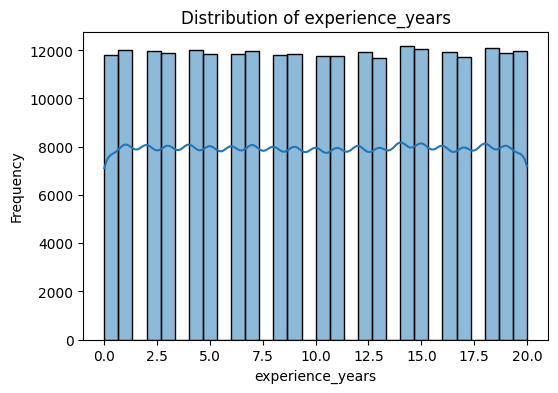

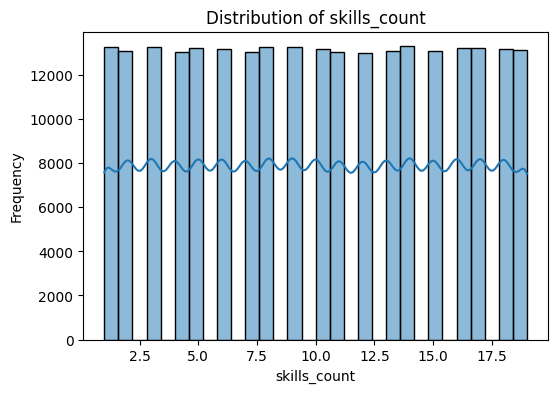

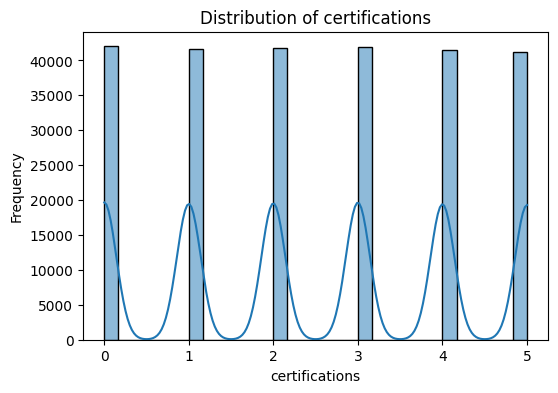

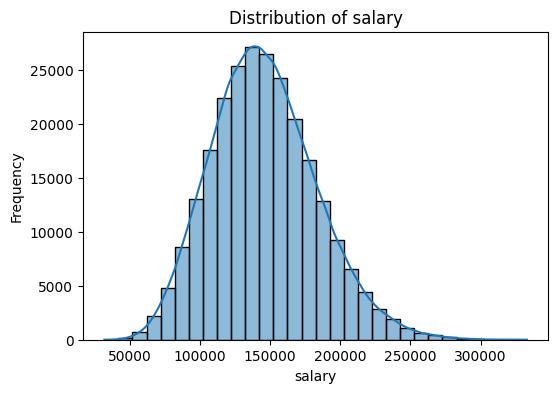

In [ ]:
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde = True,bins=30)

    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.title(f'Distribution of {col}')

    plt.show()

> ## **Insights from Histogram & KDE Plots:**

> ### **1. Experience (experience_years)**
The distribution of experience years appears uniform, meaning values are evenly spread across the range (0–20 years). There is no strong skewness or concentration in a specific range. This indicates that the dataset contains a balanced representation of both less experienced and highly experienced individuals, which is beneficial for model learning.

---

> ### **2. Skills Count (skills_count)**
The skills count feature also shows a uniform distribution, with values evenly distributed across the range. This suggests that employees with both low and high skill counts are equally represented in the dataset. Since there is no skewness, this feature is less likely to bias the model.

---

> ### **3. Certifications (certifications)**
The certifications feature is discrete and categorical-like, with distinct peaks at integer values (0 to 5). This indicates that the data is not continuous but grouped into specific categories. Such features may not behave like continuous variables and should be handled carefully during preprocessing, although KNN can still work with them after scaling.

---

> ### **4. Salary (Target Variable)**
The salary distribution follows an approximately normal (bell-shaped) distribution, with most values concentrated around the middle range (120k–180k). There is a slight right tail, indicating a few higher salary values. A near-normal distribution is beneficial for modeling, as it suggests stable patterns without extreme skewness.

---

> ## **Overall Insights**
Overall, most numerical features are either uniformly distributed or normally distributed, with minimal skewness. The dataset does not show strong imbalance in feature distributions, which is advantageous for machine learning models. However, since KNN is a distance-based algorithm, applying feature scaling (StandardScaler) remains essential to ensure all features contribute equally to distance calculations.

---


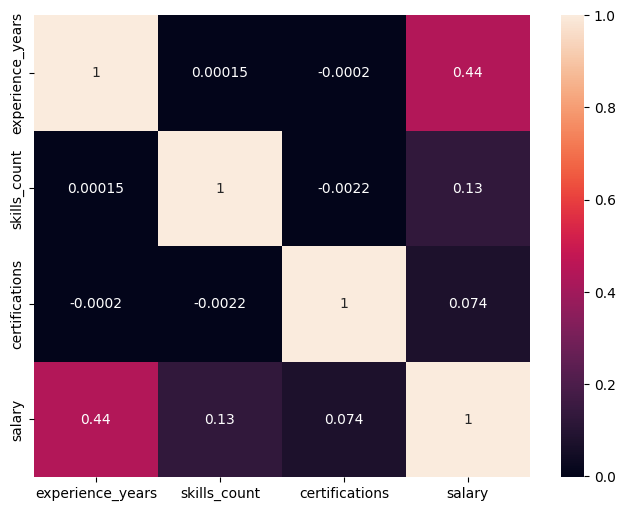

In [ ]:
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

> ## Insights from Correlation Heatmap:

> ### 1. Experience vs Salary
Experience shows a moderate positive correlation (0.44) with salary. This indicates that as experience increases, salary tends to increase as well. Among all features, experience is the most important predictor of salary in this dataset.

---

> ###  2. Skills Count vs Salary
Skills count has a weak positive correlation (0.13) with salary. This suggests that having more skills slightly increases salary, but the impact is not very strong compared to experience.

---

> ###  3. Certifications vs Salary
Certifications show a very weak positive correlation (0.074) with salary. This indicates that certifications have minimal direct influence on salary in this dataset.

---

> ###  4. Feature Relationships (Independent Variables)
The correlations between independent features (experience, skills, certifications) are all close to zero, meaning:
- Features are largely independent
- There is no multicollinearity issue
- Each feature contributes unique information to the model

---

> ##  Overall Insights
Overall,experience is the strongest factor influencing salary, followed by skills count, while certifications have minimal impact. The low correlation among input features is beneficial, as it reduces redundancy and improves model stability.

> Even though some features have weak correlations, they may still contribute to prediction when used together, especially in non-linear models like KNN.

---


# **Select Target Variable and Predictors**

In [ ]:
y = df['salary']
X = df.drop('salary', axis=1)
print(y.shape)
print(X.shape)

(250000,)
(250000, 9)


> ## **4.2 — Train-Test Split**

> **Why do we split data BEFORE preprocessing?**  
> We split first to simulate real-world conditions. If we preprocess on the entire dataset (e.g., computing mean for imputation, or scaling with StandardScaler), information from the **test set leaks into the training process** — this is called **data leakage**. The test set must remain completely "unseen" until final evaluation. All preprocessing statistics (mean, std, encoder categories) must be learned from training data only.

# **Split Data into Training and Testing Sets**

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(200000, 9)
(50000, 9)
(200000,)
(50000,)


## **4.3 — Identify Feature Types**

## **Feature Categorization**

### Numerical Columns
These columns contain continuous or discrete numerical values:

- `experience_years`
- `skills_count`
- `certifications`

---

### **Nominal Categorical Columns (No Order)**
These columns represent categories with **no inherent ranking**, so we use **One-Hot Encoding**:

- `job_title`
- `industry`
- `location`
- `remote_work`

---

### **Ordinal Categorical Columns (With Order)**
These columns have a natural order or ranking, so we use Ordinal Encoding:

- `education_level`
- `company_size`

---

### **Summary**
- **Numerical Features** → Used directly (or scaled if needed)  
- **Nominal Features** → Apply **OneHotEncoder**  
- **Ordinal Features** → Apply **OrdinalEncoder**
-----

In [ ]:
for col in df.columns:
    print(f"\n Column: {col}")
    print(df[col].value_counts())


 Column: job_title
job_title
Backend Developer            21125
Cybersecurity Analyst        20959
Product Manager              20950
AI Engineer                  20945
Data Scientist               20890
DevOps Engineer              20889
Software Engineer            20876
Data Analyst                 20722
Cloud Engineer               20686
Machine Learning Engineer    20677
Business Analyst             20648
Frontend Developer           20633
Name: count, dtype: int64

 Column: experience_years
experience_years
14    12166
18    12102
15    12052
1     12011
4     12001
7     11981
20    11958
2     11950
12    11944
16    11908
3     11890
19    11875
5     11862
6     11860
9     11856
8     11822
0     11804
10    11777
11    11747
17    11735
13    11699
Name: count, dtype: int64

 Column: education_level
education_level
Master         50352
High School    50065
Bachelor       49950
PhD            49857
Diploma        49776
Name: count, dtype: int64

 Column: skills_count
skills

# **Part 5 — Data Preprocessing**


> ### **What Does Scaling Do? Why Is It Important?**
Scaling transforms numerical features so they all live on a comparable scale (e.g., mean=0, std=1 for StandardScaler).

> **Why is it critical for KNN?**  
KNN measures distance between data points. If `experience_years` ranges from 0–20 and `salary` ranges from 30K–330K, the salary dimension will dominate the distance calculation and experience will be ignored. Scaling ensures every feature contributes fairly to the distance metric.

>**StandardScaler** transforms each feature: `z = (x - mean) / std`
---

# **Part 6 — Build Full Pipeline**

> ## **How Does a Pipeline Help Prevent Data Leakage?**  
> A `sklearn Pipeline` chains all steps (imputation → encoding → scaling → model) into a single object.

>When you call `pipeline.fit(X_train, y_train)`, every transformer **learns its parameters only from training data**.

>When you call `pipeline.predict(X_test)`, the same learned parameters are applied to the test set — the test data never influences any transformation step. Without a pipeline, it's easy to accidentally `fit_transform` on all data before splitting.

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder,StandardScaler
knn_pipe=Pipeline (steps=[("t1", ColumnTransformer(transformers=[("t1",OrdinalEncoder(),[2,5]),
                          ("t2",OneHotEncoder(),[0,4,6,7]),
                          ("t3", StandardScaler(),[1,3,8])])),
                          ("t4", KNeighborsRegressor())])

In [ ]:
knn_pipe.fit(X_train, y_train)

Pipeline(steps=[('t1',
                 ColumnTransformer(transformers=[('t1', OrdinalEncoder(),
                                                  [2, 5]),
                                                 ('t2', OneHotEncoder(),
                                                  [0, 4, 6, 7]),
                                                 ('t3', StandardScaler(),
                                                  [1, 3, 8])])),
                ('t4', KNeighborsRegressor())])

In [ ]:
y_pred=knn_pipe.predict(X_test)
print(y_pred.shape)
print(y_test.shape)

(50000,)
(50000,)


# **Part 7 — Evaluate the Model**

> ## Since this is a **Regression** problem, we evaluate using:
- **MAE** — Mean Absolute Error: average difference between predicted and actual salary
- **MSE** — Mean Squared Error: average of squared differences between predicted and actual salary; strongly penalises large errors, making it sensitive to outliers
- **RMSE** — Root Mean Squared Error: penalises large errors more heavily than MAE
- **R² Score** — Proportion of salary variance explained by the model (1.0 = perfect)

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
print("Mean Squared Error is ", mean_squared_error(y_pred, y_test))
print("Mean Absolute Error is ", mean_absolute_error(y_pred,y_test))
print("R2 Score is ",r2_score (y_pred,y_test))
print("Root Mean Squared Error is ",np.sqrt(mean_squared_error(y_pred, y_test)))

Mean Squared Error is  158323388.91664562
Mean Absolute Error is  9721.073675999998
R2 Score is  0.8475810266883474
Root Mean Squared Error is  12582.662234862923


# Model Interpretation

## **Is the model good?**  
> An R² score above **0.70** means the model explains the majority of salary variance — that's a solid result for a KNN model on structured HR data. The MAE tells us the average prediction is off by approximately that dollar amount, which in context of salaries ranging from 31K to 333K is acceptable.

## **Where does it fail?**  
> - KNN can struggle with **outliers** — a few extreme salaries (very high or very low) will produce large residuals.
> - KNN is sensitive to **irrelevant features** — if a feature like `job_title` has many unique values after one-hot encoding, it can add noise.
> - KNN predictions on employees at the **extreme ends** (very junior or very senior) may be less accurate because fewer similar neighbours exist.

## **How can we improve it?**  
> 1. **Feature Engineering** — Create interaction features like `experience × education_level`
> 2. **Better K selection** — Use cross-validation grid search for optimal K
> 3. **Try alternative metrics** — Test Manhattan vs Euclidean distance
> 4. **Dimensionality reduction** — Apply PCA to reduce noise from one-hot encoded columns
> 5. **Ensemble models** — Random Forest or Gradient Boosting typically outperform KNN on tabular data